# Action Recognition
 Foundations of Machine Learning SS26    
 Group 11 - G. Sammet, M. Schlichting
### Dataset 
- RGB videos
    - ca 2 seconds long
    - resolution 1920x1080
- ca. 900 videos per action
- 4 actions: waving, capitulate, cross arms and clapping

    **Aquisition:**    
    We contacted ROSE Lab to get permission for the download. Due to hardware limits we downloaded the zip files in batched and ran the ``process_NTU.py`` to extract only the action classes we wanted.

    *The research in this project used the NTU RGB+D (or NTU RGB+D 120) Action Recognition Dataset made available by the ROSE Lab at the Nanyang Technological University, Singapore.*

    ROSE Lab. Action recognition datasets: “NTU RGB+D” dataset and “NTU RGB+D 120” dataset [Dataset]. https://rose1.ntu.edu.sg/dataset/actionRecognition/  

### Imports

In [113]:
from pathlib import Path
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix

import random
from PIL import Image
import matplotlib.pyplot as plt
import string
import numpy as np
import os
import pandas as pd
import seaborn as sns
import copy

import optuna
from IPython.display import Video, display
import cv2

## Experiment 1
### Model 1a: Simple One-Frame-Model
single frame -> pre-trained ResNet18 -> custom classifier output layer

### Load ResNet18 Model & Dataset

In [114]:
# load pretrained model
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# modify last layer to 4 classes
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 4)

# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)

# define transformations for our dataset
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Training Loop

In [115]:
# training loop 
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    # determine device
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    best_val_acc = 0.0
    best_model_state = None
    best_epoch = 0

    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())

    return best_model_state, best_epoch, best_val_acc

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model1a = resnet_model.to(device)
# load data and transform
output_dir = Path("data/three_quarter_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_model1 = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_model1 = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_model1 = DataLoader(test_dataset, batch_size=32, shuffle=False)


if False: # set to True to train model 
    # train model
    best_model_state, best_epoch, best_val_acc = train(model1a, train_loader_model1, val_loader_model1, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model1a_state_dict": best_model_state,
        "optimizer_model1a_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model1a_checkpoint.pth"
    )

Epoch [1/10], train loss: 1.2193, train acc: 0.4066, val loss: 1.0036, val acc: 0.5263 

Epoch [2/10], train loss: 0.9381, train acc: 0.5836, val loss: 0.8669, val acc: 0.6228 

Epoch [3/10], train loss: 0.8521, train acc: 0.6291, val loss: 0.8191, val acc: 0.6474 

Epoch [4/10], train loss: 0.7951, train acc: 0.6595, val loss: 0.8026, val acc: 0.6509 

Epoch [5/10], train loss: 0.7758, train acc: 0.6625, val loss: 0.7674, val acc: 0.6561 

Epoch [6/10], train loss: 0.7462, train acc: 0.6892, val loss: 0.7610, val acc: 0.6596 

Epoch [7/10], train loss: 0.7296, train acc: 0.6926, val loss: 0.7462, val acc: 0.6754 

Epoch [8/10], train loss: 0.7100, train acc: 0.6994, val loss: 0.7210, val acc: 0.6825 

Epoch [9/10], train loss: 0.6981, train acc: 0.7054, val loss: 0.7165, val acc: 0.6737 

Epoch [10/10], train loss: 0.6790, train acc: 0.7133, val loss: 0.7177, val acc: 0.6702 



### Evaluation Function

In [117]:
def evaluate_model(model, test_loader, device):
    # evaluation mode
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # collect preds and labels
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    class_names = test_loader.dataset.classes

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4,
        output_dict=True,
        zero_division=0
    )
    # Overall accuracy
    overall_accuracy = report["accuracy"]

    # F1 score per class
    f1_per_class = {
        classname: report[classname]["f1-score"]
        for classname in class_names
    }
    print(f"Overall Accuracy: {overall_accuracy:.4f}\n")
    print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=test_loader.dataset.classes,
        yticklabels=test_loader.dataset.classes
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return f1_per_class, overall_accuracy

Overall Accuracy: 0.6702

              precision    recall  f1-score   support

      class1     0.9728    0.9931    0.9828       144
      class2     0.5581    0.5035    0.5294       143
      class3     0.5492    0.7413    0.6310       143
      class4     0.6058    0.4406    0.5101       143

    accuracy                         0.6702       573
   macro avg     0.6715    0.6696    0.6633       573
weighted avg     0.6720    0.6702    0.6639       573



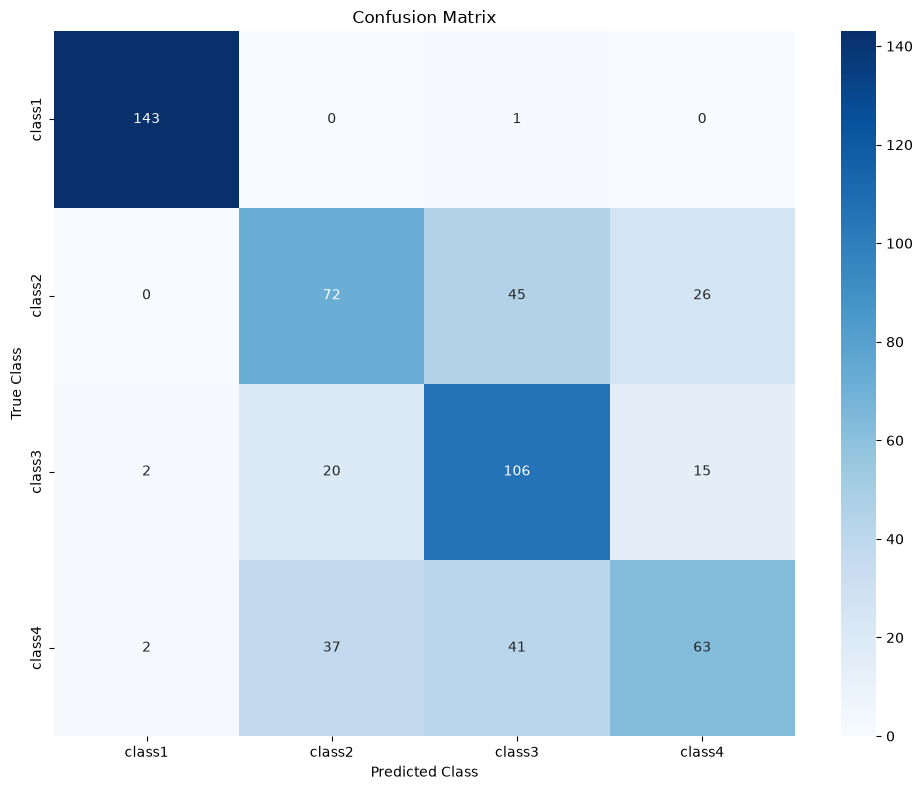

In [118]:
# load model
checkpoint = torch.load("checkpoints/model1a_checkpoint.pth",map_location=device)

model1a.load_state_dict(checkpoint["model1a_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model1a_state_dict"])
model1a.to(device)

#evaluate
f1_scores_model1a, acc_model1a = evaluate_model(model1a, test_loader_model1, device)

### Model 1b: Hyperparameter Tuning 

In [119]:
def objective(trial):
    # Hyperparameters to search
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float(
        "weight_decay", 1e-6, 1e-2, log=True
    )
    optimizer_name = trial.suggest_categorical(
        "optimizer", ["SGD", "Adam"]
    )

    # Fresh pretrained model for every trial
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    model.fc = torch.nn.Linear(model.fc.in_features, 4)
    model = model.to(device)

    # Only train FC
    if optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.8, 0.99)

        optimizer = torch.optim.SGD(
            model.fc.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )

    else:
        optimizer = torch.optim.Adam(
            model.fc.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    criterion = torch.nn.CrossEntropyLoss()

    # Train
    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader_model1:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
        print("Epoch: ", epoch)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader_model1:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total

    return val_accuracy

if False:  # set to True to run hyperparameter tuning
    study = optuna.create_study(direction="maximize")

    study.optimize(
        objective,
        n_trials=10
    )

    print("Best validation accuracy:", study.best_value)
    print("Best hyperparameters:")
    print(study.best_params)

Best validation accuracy: 0.6982456140350877    
Best hyperparameters:    
{'lr': 0.002982712257926629, 'weight_decay': 0.001431027501462824, 'optimizer': 'Adam'}

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model1b = resnet_model.to(device)
# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.fc.parameters(), lr= 0.002982712257926629, weight_decay=0.001431027501462824)

if False: # set to True to train model 
    # train model
    best_model_state, best_epoch, best_val_acc = train(model1b, train_loader_model1, val_loader_model1, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model1b_state_dict": best_model_state,
        "optimizer_model1b_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model1b_checkpoint.pth"
    )

Epoch [1/10], train loss: 0.7542, train acc: 0.6640, val loss: 0.7796, val acc: 0.6421 

Epoch [2/10], train loss: 0.7228, train acc: 0.6791, val loss: 0.7831, val acc: 0.6263 

Epoch [3/10], train loss: 0.6902, train acc: 0.6967, val loss: 0.6890, val acc: 0.6842 

Epoch [4/10], train loss: 0.6905, train acc: 0.7031, val loss: 0.7015, val acc: 0.6772 

Epoch [5/10], train loss: 0.6260, train acc: 0.7174, val loss: 0.7208, val acc: 0.6737 

Epoch [6/10], train loss: 0.6320, train acc: 0.7238, val loss: 0.6785, val acc: 0.6825 

Epoch [7/10], train loss: 0.6614, train acc: 0.7091, val loss: 0.6931, val acc: 0.6737 

Epoch [8/10], train loss: 0.6357, train acc: 0.7249, val loss: 0.6697, val acc: 0.6842 

Epoch [9/10], train loss: 0.6102, train acc: 0.7351, val loss: 0.6614, val acc: 0.6930 

Epoch [10/10], train loss: 0.6040, train acc: 0.7369, val loss: 0.6454, val acc: 0.6947 



Overall Accuracy: 0.6771

              precision    recall  f1-score   support

      class1     0.9862    0.9931    0.9896       144
      class2     0.5625    0.5035    0.5314       143
      class3     0.5604    0.7133    0.6277       143
      class4     0.6017    0.4965    0.5441       143

    accuracy                         0.6771       573
   macro avg     0.6777    0.6766    0.6732       573
weighted avg     0.6782    0.6771    0.6737       573



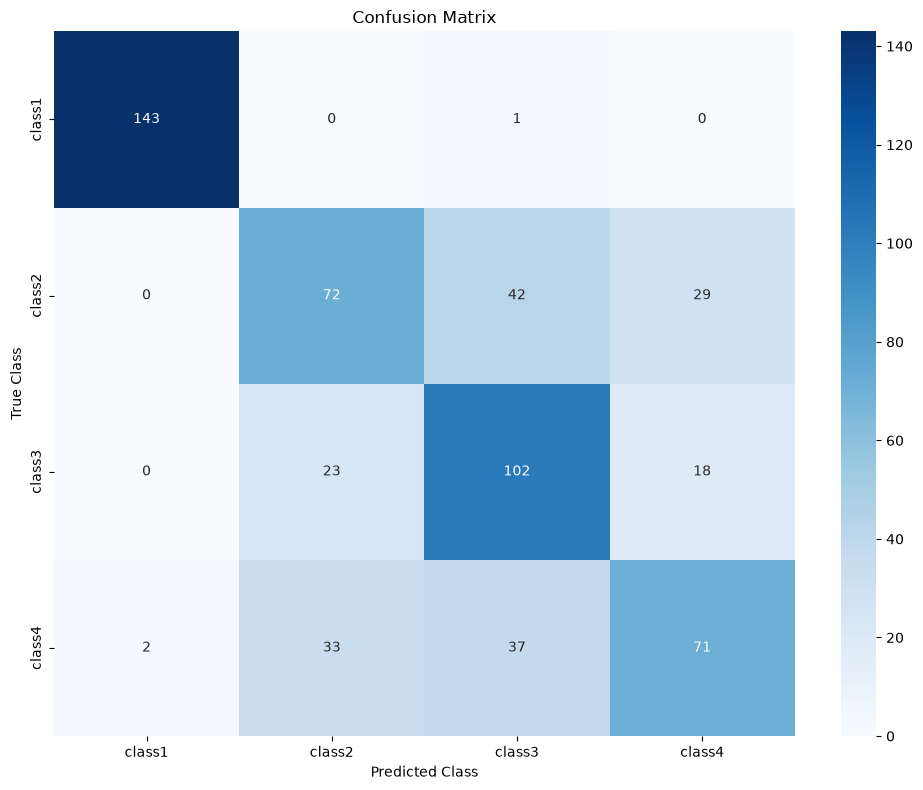

In [121]:
# load model
checkpoint = torch.load("checkpoints/model1b_checkpoint.pth",map_location=device)

model1b.load_state_dict(checkpoint["model1b_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model1b_state_dict"])
model1b.to(device)

#evaluate
f1_scores_model1b, acc_model1b = evaluate_model(model1b, test_loader_model1, device)

### Model 1c: Tuned Hyperparameter + unfrozen layer 4

In [ ]:
# load pretrained model
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# modify last layer to 4 classes
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 4)

# Freeze everything
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

# unfreeze classifier
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {"params": resnet_model.layer4.parameters(), "lr": 1e-5},
    {"params": resnet_model.fc.parameters(), 'lr': 0.002982712257926629, 'weight_decay': 0.001431027501462824},
])

model1c = resnet_model.to(device)

if False: # set to True to train model     
    # train model
    best_model_state, best_epoch, best_val_acc = train(model1c, train_loader_model1, val_loader_model1, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model1c_state_dict": best_model_state,
        "optimizer_model1c_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model1c_checkpoint.pth"
    )

Epoch [1/10], train loss: 0.9912, train acc: 0.5396, val loss: 0.7109, val acc: 0.6877 

Epoch [2/10], train loss: 0.6827, train acc: 0.7065, val loss: 0.6162, val acc: 0.7088 

Epoch [3/10], train loss: 0.4992, train acc: 0.7854, val loss: 0.5736, val acc: 0.7386 

Epoch [4/10], train loss: 0.3888, train acc: 0.8414, val loss: 0.5897, val acc: 0.7211 

Epoch [5/10], train loss: 0.3584, train acc: 0.8501, val loss: 0.5811, val acc: 0.7596 

Epoch [6/10], train loss: 0.2095, train acc: 0.9278, val loss: 0.5935, val acc: 0.7474 

Epoch [7/10], train loss: 0.1601, train acc: 0.9572, val loss: 0.6113, val acc: 0.7544 

Epoch [8/10], train loss: 0.1135, train acc: 0.9756, val loss: 0.6501, val acc: 0.7544 

Epoch [9/10], train loss: 0.0811, train acc: 0.9808, val loss: 0.6354, val acc: 0.7754 

Epoch [10/10], train loss: 0.0575, train acc: 0.9902, val loss: 0.7189, val acc: 0.7702 



Overall Accuracy: 0.7749

              precision    recall  f1-score   support

      class1     1.0000    1.0000    1.0000       144
      class2     0.6316    0.6713    0.6508       143
      class3     0.7714    0.7552    0.7633       143
      class4     0.7007    0.6713    0.6857       143

    accuracy                         0.7749       573
   macro avg     0.7759    0.7745    0.7750       573
weighted avg     0.7763    0.7749    0.7753       573



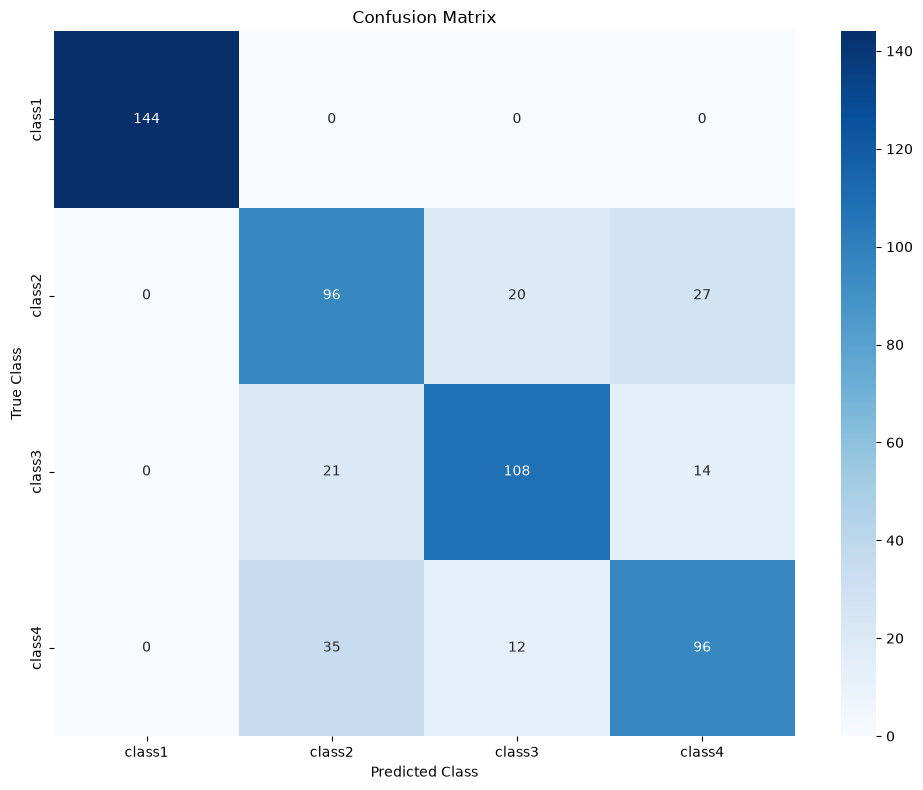

In [123]:
# load model
checkpoint = torch.load("checkpoints/model1c_checkpoint.pth",map_location=device)

model1c.load_state_dict(checkpoint["model1c_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model1c_state_dict"])
model1c.to(device)

#evaluate
f1_scores_model1c, acc_model1c = evaluate_model(model1c, test_loader_model1, device)

## Experiment 2: Three-Models-Approach
3 frames per video -> one model per frame type -> average over class predictions -> classification

#### Model 2: Middle-Frame-Model

In [124]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(resnet_model.fc.parameters(), lr= 0.002982712257926629, weight_decay=0.001431027501462824)

# load datat for middle frame
output_dir = Path("data/middle_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_model2 = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_model2 = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_model2 = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model2 = resnet_model.to(device)

# set True to train model
if False: # set to True to train model 
    # train model
    best_model_state, best_epoch, best_val_acc = train(model2, train_loader_model2, val_loader_model2, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model2_state_dict": best_model_state,
        "optimizer_model2_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model2_checkpoint.pth"
    )

Epoch [1/10], train loss: 0.3908, train acc: 0.8673, val loss: 0.9805, val acc: 0.6877 

Epoch [2/10], train loss: 0.3103, train acc: 0.8824, val loss: 0.9349, val acc: 0.6807 

Epoch [3/10], train loss: 0.3046, train acc: 0.8858, val loss: 0.8765, val acc: 0.6895 

Epoch [4/10], train loss: 0.2973, train acc: 0.8873, val loss: 0.9099, val acc: 0.6754 

Epoch [5/10], train loss: 0.3090, train acc: 0.8760, val loss: 1.1801, val acc: 0.6561 

Epoch [6/10], train loss: 0.2873, train acc: 0.8865, val loss: 0.8883, val acc: 0.6737 

Epoch [7/10], train loss: 0.2665, train acc: 0.8963, val loss: 0.9198, val acc: 0.6737 

Epoch [8/10], train loss: 0.2916, train acc: 0.8820, val loss: 0.9384, val acc: 0.6719 

Epoch [9/10], train loss: 0.2956, train acc: 0.8816, val loss: 0.9337, val acc: 0.6649 

Epoch [10/10], train loss: 0.2508, train acc: 0.9030, val loss: 0.9584, val acc: 0.6772 



Overall Accuracy: 0.7155

              precision    recall  f1-score   support

      class1     0.9931    0.9931    0.9931       144
      class2     0.5804    0.5804    0.5804       143
      class3     0.6202    0.5594    0.5882       143
      class4     0.6624    0.7273    0.6933       143

    accuracy                         0.7155       573
   macro avg     0.7140    0.7150    0.7138       573
weighted avg     0.7145    0.7155    0.7142       573



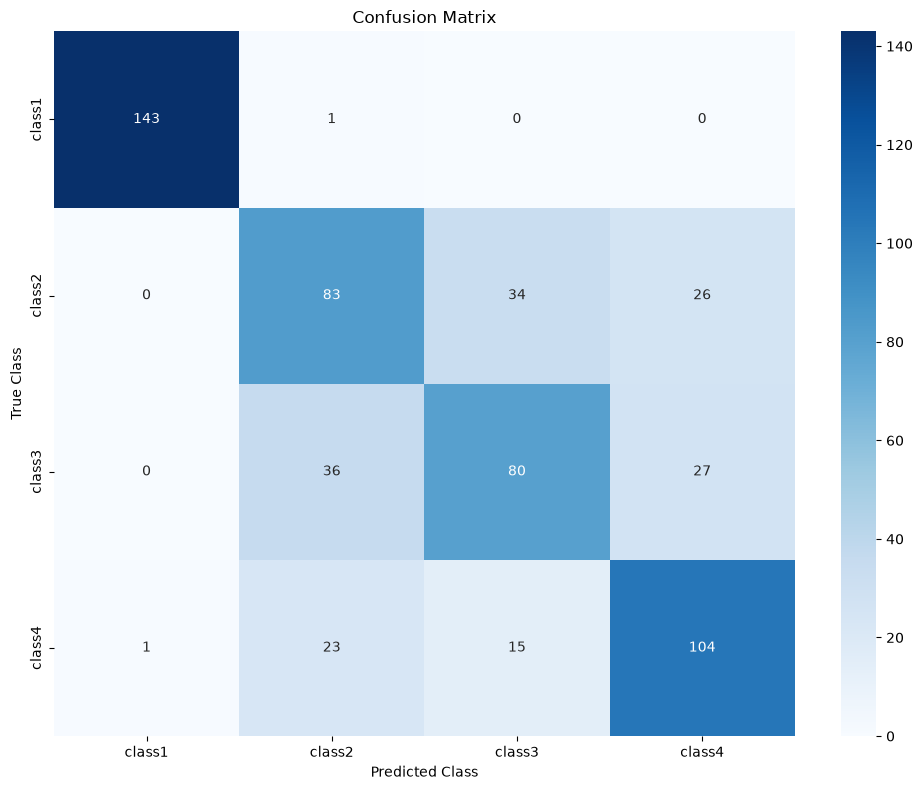

In [125]:
# load model
checkpoint = torch.load("checkpoints/model2_checkpoint.pth",map_location=device)

model2.load_state_dict(checkpoint["model2_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model2_state_dict"])
model2.to(device)

#evaluate
f1_scores_model2, acc_model2 = evaluate_model(model2, test_loader_model2, device)

#### Model 3: End-Frame-Model

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(resnet_model.fc.parameters(), lr= 0.002982712257926629, weight_decay=0.001431027501462824)

# load datat for end frame
output_dir = Path("data/end_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir / "test")), transform=transform)

train_loader_model3 = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_model3 = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_model3 = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model3 = resnet_model.to(device)

if False: # set to True to train model 
    # train model
    best_model_state, best_epoch, best_val_acc = train(model3, train_loader_model3, val_loader_model3, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model3_state_dict": best_model_state,
        "optimizer_model3_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model3_checkpoint.pth"
    )

Epoch [1/10], train loss: 0.2463, train acc: 0.9151, val loss: 0.7688, val acc: 0.7263 

Epoch [2/10], train loss: 0.2319, train acc: 0.9147, val loss: 0.8117, val acc: 0.7140 

Epoch [3/10], train loss: 0.2193, train acc: 0.9211, val loss: 0.7706, val acc: 0.7211 

Epoch [4/10], train loss: 0.2147, train acc: 0.9177, val loss: 0.7633, val acc: 0.7368 

Epoch [5/10], train loss: 0.2455, train acc: 0.9113, val loss: 0.9082, val acc: 0.7105 

Epoch [6/10], train loss: 0.2315, train acc: 0.9237, val loss: 0.7943, val acc: 0.7316 

Epoch [7/10], train loss: 0.2033, train acc: 0.9301, val loss: 0.7990, val acc: 0.7298 

Epoch [8/10], train loss: 0.2228, train acc: 0.9218, val loss: 0.8013, val acc: 0.7316 

Epoch [9/10], train loss: 0.2489, train acc: 0.9068, val loss: 0.8211, val acc: 0.7351 

Epoch [10/10], train loss: 0.1771, train acc: 0.9376, val loss: 0.8792, val acc: 0.7140 



Overall Accuracy: 0.7382

              precision    recall  f1-score   support

      class1     1.0000    1.0000    1.0000       144
      class2     0.5743    0.5944    0.5842       143
      class3     0.7260    0.7413    0.7336       143
      class4     0.6519    0.6154    0.6331       143

    accuracy                         0.7382       573
   macro avg     0.7381    0.7378    0.7377       573
weighted avg     0.7385    0.7382    0.7382       573



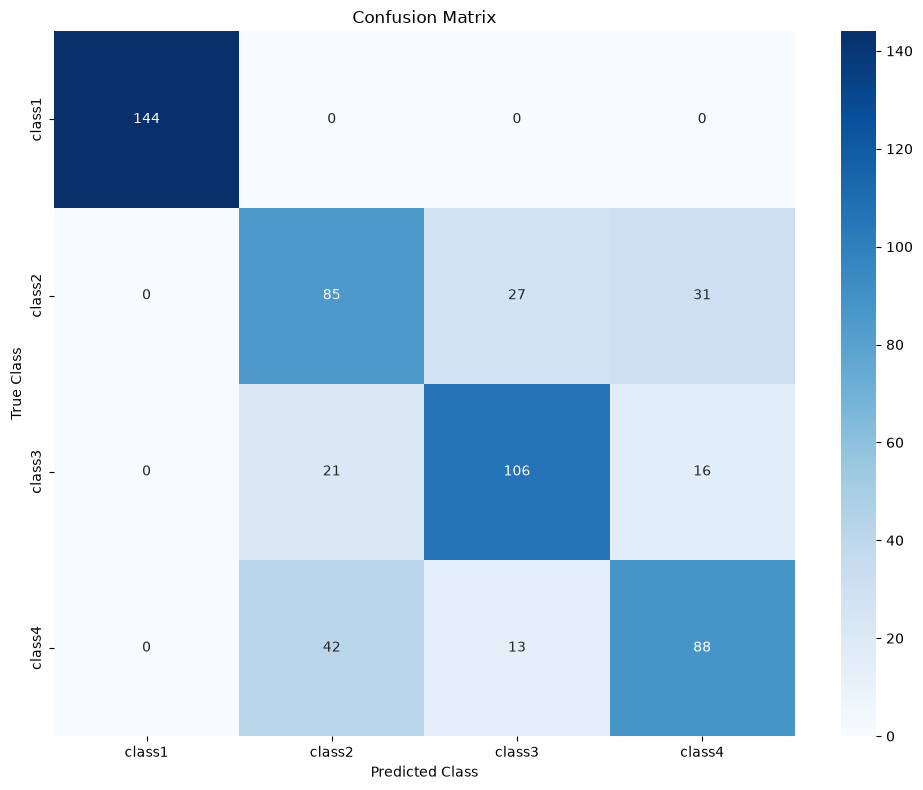

In [127]:
# load model
checkpoint = torch.load("checkpoints/model3_checkpoint.pth",map_location=device)

model3.load_state_dict(checkpoint["model3_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model3_state_dict"])
model3.to(device)

#evaluate
f1_scores_model3, acc_model3 = evaluate_model(model3, test_loader_model3, device)

### Model 4: Combine Models

In [128]:
train_loader_model1b = train_loader_model1
val_loader_model1b = val_loader_model1
test_loader_model1b =test_loader_model1

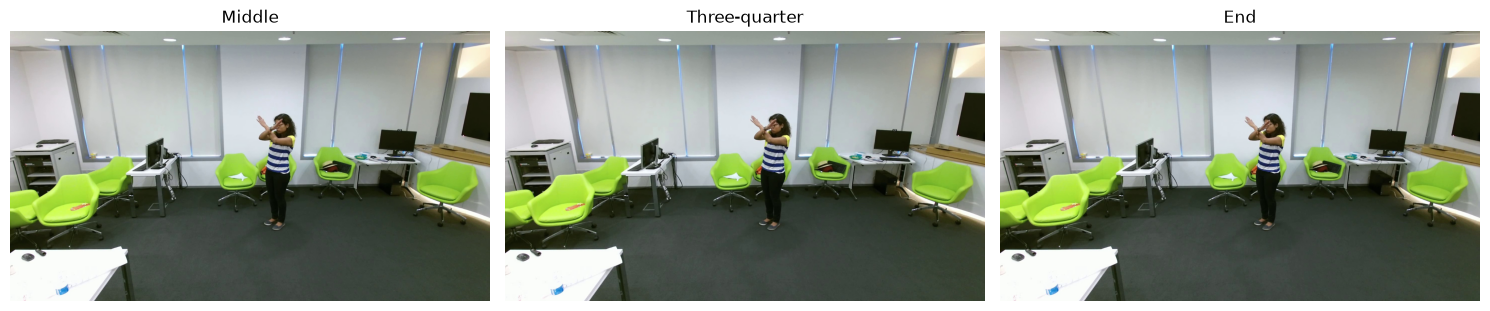

Middle Model Confidence: 99.78%
Middle Model Probabilities: tensor([[1.2157e-04, 2.8391e-04, 9.9781e-01, 1.7830e-03]], device='cuda:0')
Middle Model Prediction: Cross Arms = Class 3
---
Three-quarter Model Confidence: 83.48%
Three-quarter Model Probabilities: tensor([[0.0103, 0.0604, 0.8348, 0.0946]], device='cuda:0')
Three-quarter Model Prediction: Cross Arms = Class 3
---
End Model Confidence: 99.93%
End Model Probabilities: tensor([[2.7876e-06, 2.4885e-04, 9.9926e-01, 4.8370e-04]], device='cuda:0')
End Model Prediction: Cross Arms = Class 3
---
Overall Probabilities: tensor([[0.0035, 0.0203, 0.9439, 0.0323]], device='cuda:0')
Overall Prediction: Cross Arms = Class 3
True Label: class3


In [129]:
#random.seed(1)
def model4(device, video_name="random", display_on = True):

    class_names = ["Capitulate  = Class 1", "Clapping = Class 2", "Cross Arms = Class 3", "Hand Waving = Class 4"]
    # use same transform configuration
    transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    
    overall_probs = torch.Tensor([0,0,0,0])

    if video_name == "random":
        # choose random frame from test file
        random_frame = random.choice(list(Path("data/three_quarter_frame/test").glob("class*/*.jpg")))
        # get video name
        video_name = random_frame.name.partition("rgb")[0] + "rgb"

    # find frames 
    middle_path = next(Path("data/middle_frame/").rglob(f"{video_name}_ending.jpg"), None)
    three_quarter_path = next(Path("data/three_quarter_frame/").rglob(f"{video_name}_ending.jpg"), None)
    end_path = next(Path("data/end_frame/").rglob(f"{video_name}_ending.jpg"), None)

    paths = [
                ("Middle", middle_path),
                ("Three-quarter", three_quarter_path),
                ("End", end_path)
            ]
    
    # find true label
    true_label = three_quarter_path.parent.name

    # display frames
    if display_on:
        _, axes = plt.subplots(1, 3,figsize=(15, 5))
        
        for ax, (title, path) in zip(axes, paths):
            image = Image.open(path).convert("RGB")
            ax.imshow(image)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    overall_probs = torch.zeros(1, 4).to(device)
    # get predictions
    for (title,path), model_path in zip(paths, ["model2_", "model1b_", "model3_"]):
        # transform image
        image = Image.open(path).convert("RGB")
        frame = transform(image).unsqueeze(0).to(device)

        # get model
        model = resnet_model.to(device)
        checkpoint = torch.load(f"checkpoints/{model_path}checkpoint.pth",map_location=device)
        model.load_state_dict(checkpoint[f"{model_path}state_dict"])
        model = model.to(device)
        model.eval()

        with torch.no_grad():
            output = model(frame)
            probabilities = torch.softmax(output, dim=1)
            confidence = probabilities[0, torch.argmax(probabilities, dim=1).item()].item()
            overall_probs += probabilities

        if display_on:
            print(f"{title} Model Confidence: {confidence:.2%}")
            print(f"{title} Model Probabilities: {probabilities}")
            print(f"{title} Model Prediction: {class_names[torch.argmax(probabilities, dim=1).item()]}")
            print("---")

    overall_probs /= len(paths)
    overall_pred = overall_probs.argmax(dim=1).item()

    if display_on:
        print("Overall Probabilities:", overall_probs)
        print("Overall Prediction:", class_names[overall_pred])
        print("True Label:", true_label)

    

    return overall_pred, true_label


device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
pred, true_label =model4(device, video_name="random", display_on=True)

### Evaluation of Model 4

Overall Accuracy: 0.7435
              precision    recall  f1-score   support

      class1     1.0000    1.0000    1.0000       144
      class2     0.5926    0.5594    0.5755       143
      class3     0.7181    0.7483    0.7329       143
      class4     0.6552    0.6643    0.6597       143

    accuracy                         0.7435       573
   macro avg     0.7415    0.7430    0.7420       573
weighted avg     0.7419    0.7435    0.7425       573



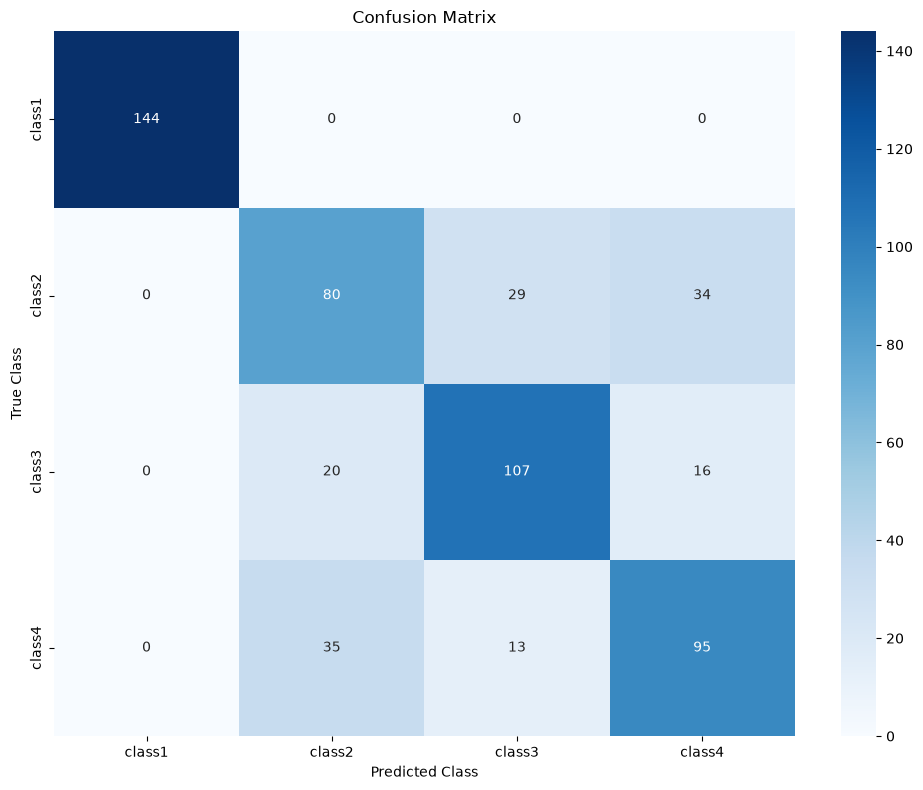

In [130]:
def evaluate_model4():

    # get all test video names
    test_dir = Path("data/end_frame/test")
    video_names = set(
        video.name.partition("rgb")[0] + "rgb"
        for class_dir in test_dir.iterdir()
        if class_dir.is_dir()
        for video in class_dir.iterdir()
        if video.is_file())

    # class names
    class_names = [f"class{i+1}" for i in range(4)]

    all_labels = []
    all_preds = []

    for video_name in video_names:

        pred, true_label = model4(device, video_name=video_name, display_on = False)
        true_label =int(true_label.strip(string.ascii_letters))-1

        all_labels.append(true_label)
        all_preds.append(pred)

    report_dict = classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            output_dict=True,
            digits=4,
            zero_division=0
        )

    # overall accuracy
    overall_accuracy = report_dict["accuracy"]

    # F1 score per class
    f1_per_class = {
        classname: report_dict[classname]["f1-score"]
        for classname in class_names
    }

    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            digits=4,
            zero_division=0
        ))
    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return f1_per_class, overall_accuracy



f1_scores_model4, acc_model4 = evaluate_model4()

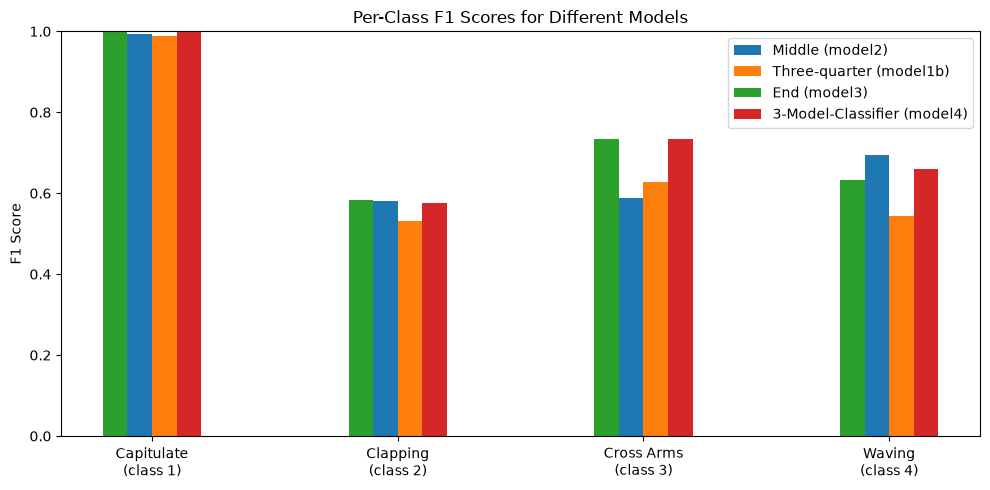

In [154]:
# plot per class f1 scores
classes = list(f1_scores_model1b.keys())
x = np.arange(len(classes))
width = 0.1

plt.figure(figsize=(10, 5))

plt.bar(x - 0.5 * width,[f1_scores_model2[c] for c in classes], width, label="Middle (model2)")
plt.bar(x + 0.5 * width, [f1_scores_model1b[c] for c in classes], width, label="Three-quarter (model1b)")
plt.bar(x - 1.5 * width,[f1_scores_model3[c] for c in classes], width, label="End (model3)")
plt.bar(x + 1.5 * width, [f1_scores_model4[c] for c in classes], width, label="3-Model-Classifier (model4)")


plt.xticks(x, ["Capitulate\n(class 1)","Clapping\n(class 2)", "Cross Arms\n(class 3)", "Waving\n(class 4)"])
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores for Different Models")
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 3: GRU

### Model 5a: ResNet18 Model + GRU

In [132]:
class GRU_model(nn.Module):
    def __init__(self, num_classes=4):
        super(GRU_model, self).__init__()
        # load pretrained model
        resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)

        # remove last fc layer
        self.feature_extractor = nn.Sequential(*list(resnet_model.children())[:-1])

        # freeze ResNet
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        # GRU
        self.gru = nn.GRU(input_size=512, hidden_size=128, batch_first=True)

        # final classifier
        self.fc = nn.Linear(128, num_classes) 


    def forward(self,x):
        batch_size, seq_len, channels, height, width = x.size()

        # use ResNet for each picture in the sequence
        x = x.view(batch_size * seq_len, channels, height, width)

        #extract features with resnet
        with torch.no_grad(): 
            features = self.feature_extractor(x)

        # bring features into right sequential form
        features = torch.flatten(features, 1)
        features = features.view(batch_size, seq_len, 512)

        #process features with gru
        _, hn = self.gru(features)

        last_hidden_state = hn[-1]

        #classify
        output = self.fc(last_hidden_state)
        return output

### Load 8-frames-per-video dataset

In [133]:
# load dataset
class VideoDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe 
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_folder = os.path.join(self.root_dir, row['frame_dir'] )
        video_class = int(row['class_id']) 
        img_sequence = sorted(os.listdir(video_folder))

        frames = []
        for img_name in img_sequence:
            img_path = os.path.join(video_folder, img_name)
            image = Image.open(img_path).convert('RGB') 
            if self.transform:
                image = self.transform(image)
            frames.append(image)

        return torch.stack(frames), video_class

# define paths
DATASET_PATH = Path(r"data/video_frames_data")
CSV_PATH = DATASET_PATH / "metadata.csv"

# load CSV
full_df = pd.read_csv(CSV_PATH)

# path problems between mac, windows, linux etc.
full_df['frame_dir'] = (
    full_df['frame_dir']
    .str.replace('\\', '/', regex=False)
)

# normalize split names
full_df['split'] = full_df['split'].str.strip().str.lower()

# load training data
train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)

# load validation data
val_df = full_df[full_df['split'] == 'val'].reset_index(drop=True)

# load test data
test_df = full_df[full_df['split'] == 'test'].reset_index(drop=True)

# Dataset and Loader
train_dataset = VideoDataset(dataframe=train_df, root_dir=DATASET_PATH, transform=transform)
train_loader_model5a = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = VideoDataset(dataframe=val_df, root_dir=DATASET_PATH, transform=transform)
val_loader_model5a = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataset = VideoDataset(dataframe=test_df, root_dir=DATASET_PATH, transform=transform)
test_loader_model5a = DataLoader(test_dataset, batch_size=8, shuffle=False)

### Training Loop for GRU Model

In [134]:
# training loop 
def gru_train(model, train_loader, val_loader, criterion, optimizer, num_epochs):

    best_val_acc = 0.0
    best_model_state = None
    best_epoch = 0
    
    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_state = model.state_dict()

    return best_model_state, best_epoch, best_val_acc

In [ ]:
# train model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model5a = GRU_model(num_classes=4).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model5a.parameters()), lr=0.001) 

if False:  # set to True to train model
    # train model
    best_model_state, best_epoch, best_val_acc = gru_train(model5a, train_loader_model5a, val_loader_model5a, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model5a_state_dict": best_model_state,
        "optimizer_model5a_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model5a_checkpoint.pth"
    )

Epoch [1/10], train loss: 1.0095, train acc: 0.4795, val loss: 0.8323, val acc: 0.5772 

Epoch [2/10], train loss: 0.8303, train acc: 0.5765, val loss: 0.7873, val acc: 0.5807 

Epoch [3/10], train loss: 0.7911, train acc: 0.6047, val loss: 0.8827, val acc: 0.5614 

Epoch [4/10], train loss: 0.8196, train acc: 0.6126, val loss: 0.7834, val acc: 0.5772 

Epoch [5/10], train loss: 0.7448, train acc: 0.6400, val loss: 0.7817, val acc: 0.5667 

Epoch [6/10], train loss: 0.7222, train acc: 0.6550, val loss: 0.7795, val acc: 0.5825 

Epoch [7/10], train loss: 0.7245, train acc: 0.6543, val loss: 0.8629, val acc: 0.5439 

Epoch [8/10], train loss: 0.7375, train acc: 0.6622, val loss: 0.7723, val acc: 0.6000 

Epoch [9/10], train loss: 0.7185, train acc: 0.6528, val loss: 0.7738, val acc: 0.5982 

Epoch [10/10], train loss: 0.6823, train acc: 0.6847, val loss: 0.8041, val acc: 0.5825 



### Evaluation for GRU Model

In [136]:
def evaluate_GRU_model(model, loader, device):
    model.eval()

    class_names = ['class1', 'class2', 'class3', 'class4']

    # Track labels and predictions
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Collect predictions and labels
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    report_dict = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        digits=4,
        zero_division=0
    )

    # Overall accuracy
    overall_accuracy = report_dict["accuracy"]

    # f1 sore per class
    f1_per_class = {
    classname: report_dict[classname]["f1-score"]
    for classname in class_names
    }
    print(f"Overall Accuracy: {overall_accuracy:.4f}\n")
    print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
        )
    )

    # Confusion matrix
    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=[0, 1, 2, 3]
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("GRU Model - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return f1_per_class, overall_accuracy

Overall Accuracy: 0.6021

              precision    recall  f1-score   support

      class1     1.0000    1.0000    1.0000       144
      class2     0.4101    0.5105    0.4548       143
      class3     0.6964    0.2727    0.3920       143
      class4     0.4564    0.6224    0.5266       143

    accuracy                         0.6021       573
   macro avg     0.6407    0.6014    0.5934       573
weighted avg     0.6414    0.6021    0.5941       573



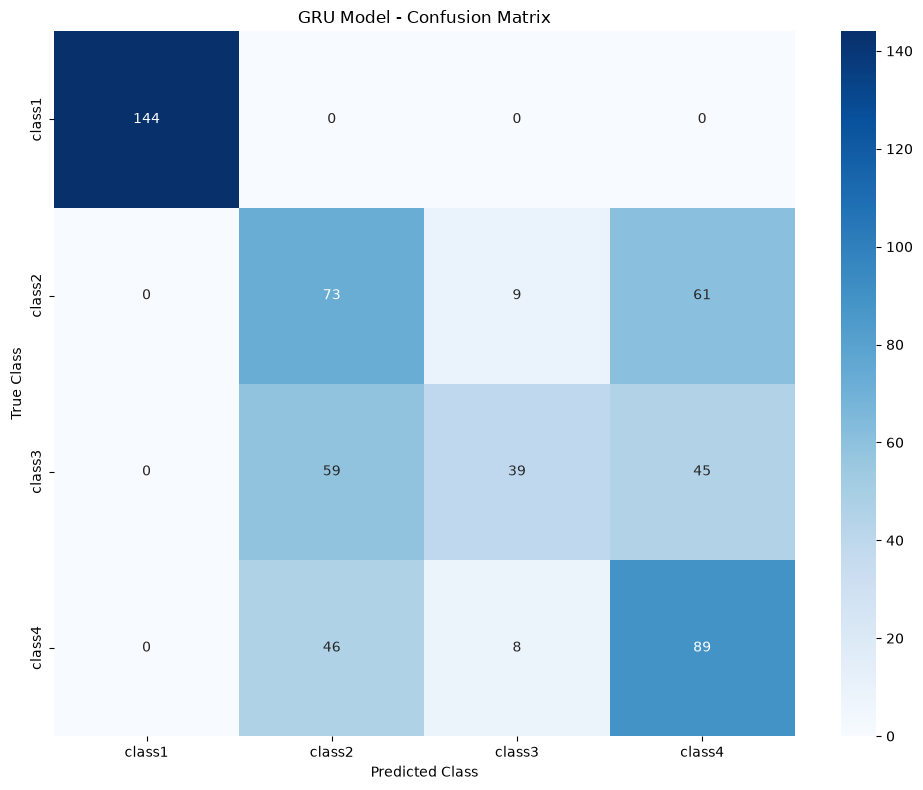

In [137]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

# load model
checkpoint = torch.load("checkpoints/model5a_checkpoint.pth",map_location=device)

model5a.load_state_dict(checkpoint["model5a_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model5a_state_dict"])
model5a.to(device)

#evaluate
f1_scores_model5a, acc_model5a = evaluate_GRU_model(model5a, test_loader_model5a, device)

### Model 5b: Hyperparameter Tuning 

In [ ]:
def objective(trial):
    # Hyperparameters to search
    lr_gru = trial.suggest_float("lr_gru", 1e-5, 1e-2, log=True)
    lr_fc = trial.suggest_float("lr_fc", 1e-5, 1e-2, log=True)
    weight_decay_gru = trial.suggest_float(
        "weight_decay_gru", 1e-6, 1e-2, log=True
    )
    weight_decay_fc = trial.suggest_float(
        "weight_decay_fc", 1e-6, 1e-2, log=True
    )

    # Fresh pretrained model for every trial
    model = GRU_model(num_classes=4).to(device)


    optimizer_params = [
        {"params": model.gru.parameters(), "lr": lr_gru, "weight_decay": weight_decay_gru},
        {"params": model.fc.parameters(), "lr": lr_fc, "weight_decay": weight_decay_fc}
    ]


    optimizer = torch.optim.Adam(optimizer_params)


    criterion = torch.nn.CrossEntropyLoss()

    # Train
    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader_model5a:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
        print("Epoch: ", epoch)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader_model5a:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total

    return val_accuracy

if False:  # set to True to run hyperparameter tuning
    study = optuna.create_study(direction="maximize")

    study.optimize(
        objective,
        n_trials=10
    )

    print("Best validation accuracy:", study.best_value)
    print("Best hyperparameters:")
    print(study.best_params)

Best validation accuracy: 0.6210526315789474    
Best hyperparameters:     
{'lr_gru': 0.000793245264589983, 'lr_fc': 0.0005781489927556018, 'weight_decay': 1.7236963877654533e-05, 'weight_decay_fc': 1.0015339385180107e-05}

In [ ]:
# train model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model5b = GRU_model(num_classes=4).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [
        {"params": model5b.gru.parameters(), "lr": 0.000793245264589983, "weight_decay": 1.7236963877654533e-05},
        {"params": model5b.fc.parameters(), "lr": 0.0005781489927556018, "weight_decay": 1.0015339385180107e-05},
    ]
)

if False:  # set to True to train model
    # train model
    best_model_state, best_epoch, best_val_acc = gru_train(model5b, train_loader_model5a, val_loader_model5a, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model5b_state_dict": best_model_state,
        "optimizer_model5b_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model5b_checkpoint.pth"
    )

Epoch [1/10], train loss: 1.0422, train acc: 0.4735, val loss: 0.8411, val acc: 0.5526 

Epoch [2/10], train loss: 0.8711, train acc: 0.5520, val loss: 0.8249, val acc: 0.5649 

Epoch [3/10], train loss: 0.7909, train acc: 0.5983, val loss: 0.8185, val acc: 0.5544 

Epoch [4/10], train loss: 0.7759, train acc: 0.6141, val loss: 0.7987, val acc: 0.5649 

Epoch [5/10], train loss: 0.7486, train acc: 0.6381, val loss: 0.7580, val acc: 0.5947 

Epoch [6/10], train loss: 0.7105, train acc: 0.6509, val loss: 0.8076, val acc: 0.5719 

Epoch [7/10], train loss: 0.7021, train acc: 0.6610, val loss: 0.7915, val acc: 0.6035 

Epoch [8/10], train loss: 0.7181, train acc: 0.6731, val loss: 0.8114, val acc: 0.5947 

Epoch [9/10], train loss: 0.6641, train acc: 0.6949, val loss: 0.8073, val acc: 0.5860 

Epoch [10/10], train loss: 0.6659, train acc: 0.6937, val loss: 0.7779, val acc: 0.6018 



Overall Accuracy: 0.6300

              precision    recall  f1-score   support

      class1     1.0000    1.0000    1.0000       144
      class2     0.5738    0.2448    0.3431       143
      class3     0.4795    0.8182    0.6047       143
      class4     0.5242    0.4545    0.4869       143

    accuracy                         0.6300       573
   macro avg     0.6444    0.6294    0.6087       573
weighted avg     0.6450    0.6300    0.6094       573



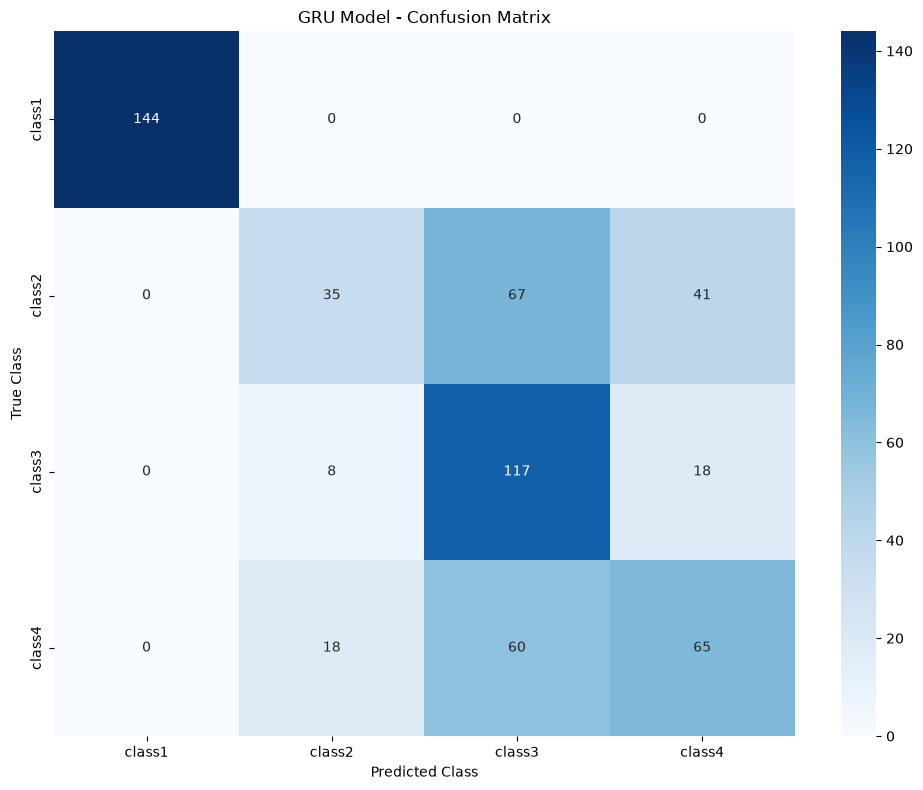

In [140]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

# load model
checkpoint = torch.load("checkpoints/model5b_checkpoint.pth",map_location=device)

model5b.load_state_dict(checkpoint["model5b_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model5b_state_dict"])
model5b.to(device)

#evaluate
f1_scores_model5b, acc_model5b = evaluate_GRU_model(model5b, test_loader_model5a, device)

### Model 5c: Original Hyperparameters + Temporal Differences

In [141]:
class GRU_model_5c(nn.Module):
    def __init__(self, num_classes=4):
        super(GRU_model_5c, self).__init__()
        # load pretrained model
        resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)

        # remove last fc layer
        self.feature_extractor = nn.Sequential(*list(resnet_model.children())[:-1])

        # freeze ResNet
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        # GRU
        self.gru = nn.GRU(input_size=512, hidden_size=128, batch_first=True)

        # final classifier
        self.fc = nn.Linear(128, num_classes) 

    def forward(self,x):
        batch_size, seq_len, channels, height, width = x.size()

        # use ResNet for each picture in the sequence
        x = x.view(batch_size * seq_len, channels, height, width)

        #extract features with resnet
        with torch.no_grad(): 
            features = self.feature_extractor(x)

        # bring features into right sequential form
        features = torch.flatten(features, 1)
        features = features.view(batch_size, seq_len, 512)
        # Temporal differences
        features = features[:, 1:, :] - features[:, :-1, :]

        #process features with gru
        _, hn = self.gru(features)

        last_hidden_state = hn[-1]

        #classify
        output = self.fc(last_hidden_state)
        return output

In [ ]:
# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model5c = GRU_model_5c(num_classes=4).to(device)

# Define loss function
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [
        {"params": model5c.gru.parameters(), "lr": 0.000793245264589983, "weight_decay": 1.7236963877654533e-05},
        {"params": model5c.fc.parameters(), "lr": 0.0005781489927556018, "weight_decay": 1.0015339385180107e-05},
    ]
)

if False:
    # train model
    best_model_state, best_epoch, best_val_acc = gru_train(model5c, train_loader_model5a, val_loader_model5a, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model5c_state_dict": best_model_state,
        "optimizer_model5c_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "val_acc": best_val_acc,
    }

    torch.save(
        checkpoint,
        "checkpoints/model5c_checkpoint.pth"
    )

Epoch [1/10], train loss: 1.2943, train acc: 0.3968, val loss: 1.0892, val acc: 0.5684 

Epoch [2/10], train loss: 0.8764, train acc: 0.6449, val loss: 0.8381, val acc: 0.6351 

Epoch [3/10], train loss: 0.6359, train acc: 0.7580, val loss: 0.7876, val acc: 0.6719 

Epoch [4/10], train loss: 0.4513, train acc: 0.8358, val loss: 0.8014, val acc: 0.6702 

Epoch [5/10], train loss: 0.2982, train acc: 0.8921, val loss: 0.8151, val acc: 0.6509 

Epoch [6/10], train loss: 0.1919, train acc: 0.9372, val loss: 0.8889, val acc: 0.6912 

Epoch [7/10], train loss: 0.1202, train acc: 0.9635, val loss: 0.9966, val acc: 0.6684 

Epoch [8/10], train loss: 0.0659, train acc: 0.9868, val loss: 1.0578, val acc: 0.6702 

Epoch [9/10], train loss: 0.0476, train acc: 0.9880, val loss: 1.3068, val acc: 0.6526 

Epoch [10/10], train loss: 0.0332, train acc: 0.9932, val loss: 1.2440, val acc: 0.6789 



Overall Accuracy: 0.6614

              precision    recall  f1-score   support

      class1     0.8615    0.7778    0.8175       144
      class2     0.6154    0.5594    0.5861       143
      class3     0.7120    0.6224    0.6642       143
      class4     0.5213    0.6853    0.5921       143

    accuracy                         0.6614       573
   macro avg     0.6775    0.6612    0.6650       573
weighted avg     0.6779    0.6614    0.6652       573



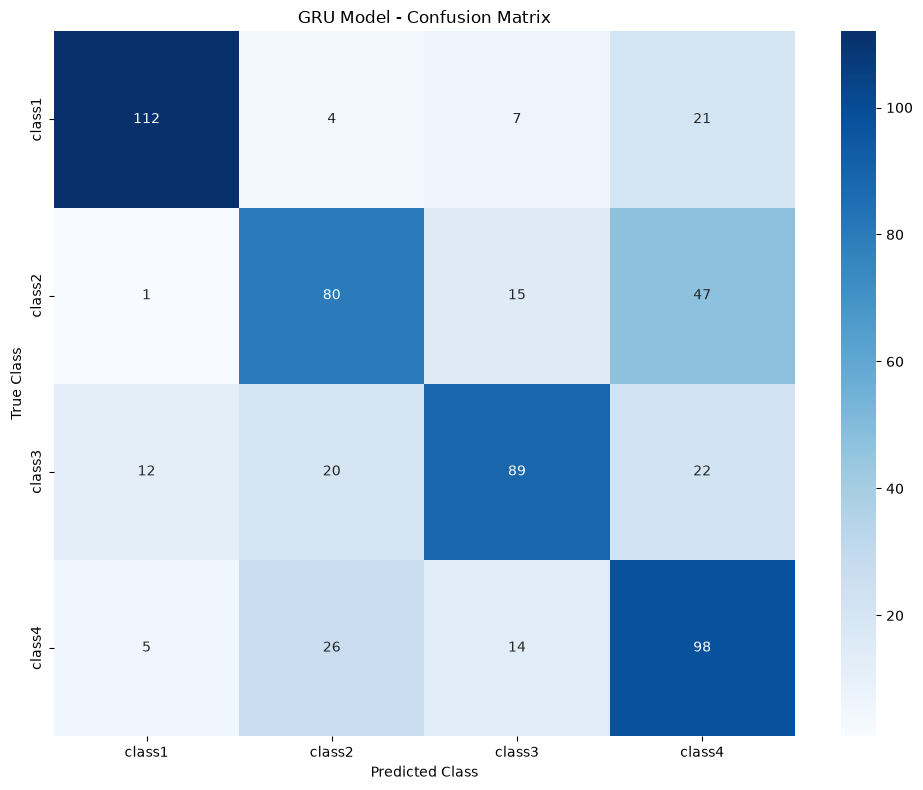

In [152]:
# load model
checkpoint = torch.load("checkpoints/model5c_checkpoint.pth",map_location=device)

model5c.load_state_dict(checkpoint["model5c_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model5c_state_dict"])
model5c.to(device)

#evaluate
f1_scores_model5c, acc_model5c = evaluate_GRU_model(model5c, test_loader_model5a, device)

# Model Comparison & Visualization

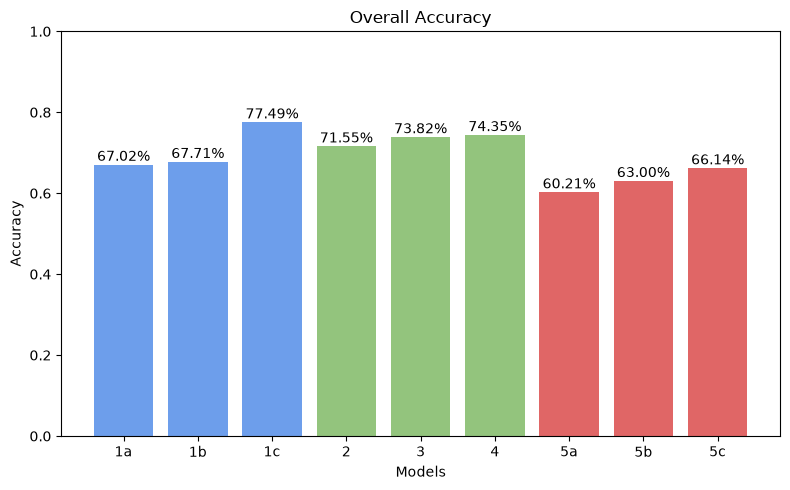

In [155]:
total_acc = [
    acc_model1a,
    acc_model1b,   
    acc_model1c,
    acc_model2,
    acc_model3,
    acc_model4,
    acc_model5a, 
    acc_model5b,
    acc_model5c]

labels = ["1a",
    "1b",
    "1c",
    "2",
    "3",
    "4",
    "5a",
    "5b",
    "5c"]

colors = ["#6d9eeb"] * 3 + ["#93c47d"] * 3 + ["#e06666"] * 3

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, total_acc, color= colors)

plt.ylabel("Accuracy")
plt.title("Overall Accuracy")
plt.ylim(0, 1)
plt.xlabel("Models")


# Add values above bars
for bar, acc in zip(bars, total_acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [147]:
f1_scores =[f1_scores_model1a, f1_scores_model1b, f1_scores_model1c, f1_scores_model2, f1_scores_model3, f1_scores_model4, f1_scores_model5a, f1_scores_model5b, f1_scores_model5c]

df = pd.DataFrame({
    "Model": labels,
    "Accuracy": total_acc})

f1_df = pd.DataFrame(f1_scores)

df = pd.concat([df, f1_df], axis=1)
df = df.round(3)

print(df)


  Model  Accuracy  class1  class2  class3  class4
0    1a     0.670   0.983   0.529   0.631   0.510
1    1b     0.677   0.990   0.531   0.628   0.544
2    1c     0.775   1.000   0.651   0.763   0.686
3     2     0.716   0.993   0.580   0.588   0.693
4     3     0.738   1.000   0.584   0.734   0.633
5     4     0.743   1.000   0.576   0.733   0.660
6    5a     0.602   1.000   0.455   0.392   0.527
7    5b     0.630   1.000   0.343   0.605   0.487
8    5c     0.693   0.841   0.635   0.678   0.626


# Examples for Simon Says

In [148]:
def extract_frames(video_path):
    video = cv2.VideoCapture(str(video_path))
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    output_dir = video_path.parent / video_path.stem
    output_dir.mkdir(parents=True, exist_ok=True)

    # sample 8 frames
    indices = np.linspace(0, total_frames - 1, 8, dtype=int)
    saved_frames = 0

    for idx in indices:
        video.set(cv2.CAP_PROP_POS_FRAMES, idx)
        _, frame = video.read()

        frame = cv2.resize(
            frame,
            (224, 224),
            interpolation=cv2.INTER_AREA)

        output_path = output_dir / f"frame_{saved_frames + 1:05d}.jpg"
        cv2.imwrite(str(output_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved_frames += 1
    video.release()

    return output_dir

def classify_example(video_path):
    display(
        Video(
            str(video_path),
            embed=True,
            width=200
        )
    )
    frames_path = extract_frames(video_path)
    class_names = ["Capitulate  = Class 1", "Clapping = Class 2", "Cross Arms = Class 3", "Hand Waving = Class 4"]

    # load model
    model = GRU_model(num_classes=4).to(device)
    checkpoint = torch.load("checkpoints/Experiment3_checkpoint.pth", map_location=device)
    model.load_state_dict(checkpoint["Experiment3_state_dict"])

    frames = []
    for img_path in sorted(frames_path.glob("*.jpg")):
        image = Image.open(img_path).convert("RGB")
        image = transform(image)
        frames.append(image)

    frames = torch.stack(frames).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(frames)
        probabilities = torch.softmax(output, dim=1)
    print(f"GRU-Model Prediction: {class_names[torch.argmax(probabilities, dim=1).item()]}")

    return 

In [149]:
#classify_example(Path("data/example_data/milena_class1.mp4"))
#classify_example(Path("data/example_data/kai_class3.mp4"))
#classify_example(Path("data/example_data/kai_class2.mp4"))
classify_example(Path("data/example_data/gwen_class4.mp4"))

error: OpenCV(5.0.0) /io/opencv/modules/imgproc/src/resize.cpp:4217: error: (-215:Assertion failed) !ssize.empty() in function 'resize'
